In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver 
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests

from dotenv import load_dotenv

load_dotenv()

subgraph_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

C:\Users\welcome\AppData\Local\Temp\ipykernel_16676\2858590446.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.ddg_search import DuckDuckGoSearchRun


In [2]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [3]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).text

    return {'translated_text': translated_text}

In [4]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [5]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [6]:
parent_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").text
    return {'answer_eng': answer}

In [8]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [9]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

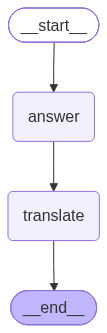

In [10]:
graph = parent_builder.compile()

graph

In [11]:
graph.invoke({'question': 'What is quantum physics'})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': 'What is quantum physics',
 'answer_eng': 'At its simplest, **quantum physics** (also known as quantum mechanics) is the study of the universe at the smallest possible scale—the level of atoms and subatomic particles (like electrons and protons). \n\nAt this microscopic level, the ordinary laws of physics that we experience in everyday life (called "classical physics") stop working. Instead, nature behaves in bizarre, counterintuitive, and seemingly magical ways.\n\nHere are the key concepts that define quantum physics, explained simply:\n\n---\n\n### 1. "Quantization" (Where the name comes from)\nIn our everyday world, energy seems continuous. You can smoothly accelerate a car from 0 to 60 mph. \nBut in the quantum world, energy exists in "packets" called **quanta**. \n* **The Analogy:** Think of a ramp versus a flight of stairs. Classical physics is like a ramp (you can stand at any height). Quantum physics is like a staircase (you can only stand on the steps, never in t